# 01  -  Health Insurance Fraud Labeling

Based on **Sowah et al. (2019)**.  
Fraud = total bill exceeds the approved G-DRG tariff ceiling from GD.csv.

**Inputs:** `data/GD.csv`, `data/ReData*.csv`  
**Output:** `outputs/health_insurance_labeled.csv`

In [1]:
exec(open('00_config.py').read())
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Config loaded. BASE_DIR: /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH


## 1. Load GD.csv  -  G-DRG Tariff Reference

In [2]:
gd = pd.read_csv(GD_CSV)
gd.columns = gd.columns.str.strip()
gd = gd.rename(columns={'Code': 'GDRG_Code', 'Cost': 'Approved_Cost'})
gd['GDRG_Code']    = gd['GDRG_Code'].astype(str).str.strip().str.upper()
gd['Approved_Cost'] = pd.to_numeric(gd['Approved_Cost'], errors='coerce')

print(f'Shape: {gd.shape}  |  codes: {gd["GDRG_Code"].nunique()}')
print(f'Cost range: {gd["Approved_Cost"].min():.2f}  -  {gd["Approved_Cost"].max():.2f} GHS')
print(gd.head(5).to_string(index=False))

Shape: (580, 3)  |  codes: 580
Cost range: 1.59  -  1441.90 GHS
GDRG_Code                                           Description  Approved_Cost
  ASUR01A Operations of thyroid and parathyroid glands >=12 Yrs         499.19
  ASUR02A        Surgery for lung and bronchus lesions >=12 Yrs         962.49
  ASUR03A        Thoracostomy and chest tube insertion >=12 Yrs         283.35
  ASUR04A   Operations on the oesophagus and diaphragm >=12 Yrs         843.55
  ASUR05A                   Excision of Neck Swellings >=12 Yrs         304.26


## 2. Load ReData Claims

In [3]:
frames = []
for fpath in REDATA_FILES:
    df = pd.read_csv(fpath)
    df['source_file'] = os.path.basename(fpath)
    frames.append(df)

claims = pd.concat(frames, ignore_index=True)
claims.columns = claims.columns.str.strip()

print(f'Total claims: {len(claims):,}')
print(claims.dtypes)

Total claims: 2,655
No.                float64
Attendance Date        str
Discharge Date         str
Age                 object
Sex                    str
Folder No              str
NHIS ID No          object
Procudure              str
Diagnosis              str
G-DRG                  str
ICD10                  str
Service            float64
Medical            float64
Total               object
source_file            str
dtype: object


## 3. Column Mapping

In [4]:
# Known from 00_DIAGNOSE_DATA.ipynb
drg_col     = 'G-DRG'
service_col = 'Service'
drug_col    = 'Medical'
total_col   = 'Total'

print(f'G-DRG  : {claims[drg_col].dropna().head(3).tolist()}')
print(claims[[service_col, drug_col, total_col]].describe().round(2))

G-DRG  : ['ASUR08A', 'ASUR08A', 'ASUR19']
       Service  Medical
count  2650.00  2026.00
mean     88.88    39.99
std      95.42    67.50
min       1.98     0.06
25%      13.27     4.00
50%      50.96    14.92
75%     130.00    48.40
max     785.26   643.83


## 4. Merge with Tariff

In [5]:
claims['GDRG_Code'] = claims[drg_col].astype(str).str.strip().str.upper()

merged = claims.merge(
    gd[['GDRG_Code', 'Approved_Cost', 'Description']],
    on='GDRG_Code', how='left'
)

match_rate = merged['Approved_Cost'].notna().mean()
print(f'Matched: {merged["Approved_Cost"].notna().sum():,} / {len(merged):,}  ({match_rate:.1%})')

if match_rate < 0.5:
    # Try stripping the age suffix (A/C) from the code
    gd['GDRG_Code_base']    = gd['GDRG_Code'].str[:-1]
    merged['GDRG_Code_base'] = merged['GDRG_Code'].str[:-1]
    test = merged.merge(
        gd[['GDRG_Code_base','Approved_Cost']].rename(columns={'Approved_Cost':'AC_base'}),
        on='GDRG_Code_base', how='left'
    )
    alt = test['AC_base'].notna().mean()
    print(f'Match rate without age suffix: {alt:.1%}')
    if alt > match_rate:
        merged['Approved_Cost'] = merged['Approved_Cost'].fillna(test['AC_base'])
        print('Using base code matching')

Matched: 1,781 / 2,655  (67.1%)


## 5. Apply Fraud Rules (Sowah et al. 2019)

- Rule 1: Service bill > approved tariff  
- Rule 2: Drug bill > 50% of approved tariff  
- Rule 3: Total bill > approved tariff  
- Rule 4: Total != Service + Drug (internal inconsistency)  
- Rule 5: Any bill <= 0

In [6]:
for col in [service_col, drug_col, total_col]:
    merged[col] = pd.to_numeric(merged[col], errors='coerce')

flags = pd.DataFrame(index=merged.index)

flags['overbill_service'] = (
    (merged[service_col] > merged['Approved_Cost']) & merged['Approved_Cost'].notna()
).astype(int)

flags['overbill_drug'] = (
    (merged[drug_col] > merged['Approved_Cost'] * 0.5) & merged['Approved_Cost'].notna()
).astype(int)

flags['overbill_total'] = (
    (merged[total_col] > merged['Approved_Cost']) & merged['Approved_Cost'].notna()
).astype(int)

expected = merged[service_col].fillna(0) + merged[drug_col].fillna(0)
flags['billing_inconsistency'] = (
    (merged[total_col] - expected).abs() > 1.0
).astype(int)

impossible = pd.Series(False, index=merged.index)
for col in [service_col, drug_col, total_col]:
    impossible |= (merged[col].fillna(0) <= 0)
flags['impossible_amount'] = impossible.astype(int)

merged['fraud_label'] = (flags.sum(axis=1) > 0).astype(int)
merged = pd.concat([merged, flags], axis=1)

fraud_rate = merged['fraud_label'].mean()
print(f'Fraud: {merged["fraud_label"].sum():,} / {len(merged):,}  ({fraud_rate:.2%})')
print(flags.sum().to_string())

Fraud: 1,105 / 2,655  (41.62%)
overbill_service           8
overbill_drug            271
overbill_total           470
billing_inconsistency      6
impossible_amount        632


## 6. Tariff Deviation Features

In [7]:
# Proportional deviation from the approved tariff
for claim_col, feat_name in [
    (service_col, 'dev_service'),
    (drug_col,    'dev_drug'),
    (total_col,   'dev_total'),
]:
    merged[feat_name] = np.where(
        merged['Approved_Cost'] > 0,
        (merged[claim_col] - merged['Approved_Cost']) / merged['Approved_Cost'],
        0
    )

# Length of stay
date_cols = [c for c in merged.columns if 'date' in c.lower()]
if len(date_cols) >= 2:
    merged['attendance_date'] = pd.to_datetime(merged[date_cols[0]], dayfirst=True, errors='coerce')
    merged['discharge_date']  = pd.to_datetime(merged[date_cols[1]], dayfirst=True, errors='coerce')
    merged['length_of_stay']  = (merged['discharge_date'] - merged['attendance_date']).dt.days.clip(lower=0)

print(merged[['dev_service','dev_drug','dev_total']].describe().round(3))

       dev_service  dev_drug  dev_total
count     2655.000  2337.000   2655.000
mean        -0.239    -0.422     -0.060
std          0.251     0.529      0.442
min         -0.963    -1.000     -0.914
25%         -0.426    -0.871     -0.314
50%         -0.261    -0.540      0.000
75%          0.000     0.000      0.000
max          4.572     6.261      6.740


## 7. Ghana-Specific Features

In [8]:
# G-DRG prefix -> MDC specialty (Sowah et al. 2019 classification)
gdrg_mdc_map = {
    'ADME': 'Adult_Medicine',   'MEDI': 'Adult_Medicine',
    'PEDI': 'Pediatrics',       'ASUR': 'Adult_Surgery',
    'PSUR': 'Pediatrics_Surgery','ENTN': 'ENT',
    'OBGY': 'Obstetrics_Gynecology','DENT': 'Dental',
    'OPHT': 'Ophthalmology',    'ORTH': 'Orthopedics',
    'RECS': 'Reconstructive_Surgery','OUTD': 'OPD', 'OPD': 'OPD',
}
merged['MDC_Specialty']   = merged['GDRG_Code'].str[:4].map(gdrg_mdc_map).fillna('Other')
merged['age_category_drg'] = merged['GDRG_Code'].str[-1].map({'A':'adult','C':'child'}).fillna('unknown')

# Common Ghana conditions (from Diagnosis column)
if 'Diagnosis' in merged.columns:
    diag = merged['Diagnosis'].astype(str).str.upper()
    merged['is_malaria']      = diag.str.contains('MALARIA',   na=False).astype(int)
    merged['is_maternal']     = diag.str.contains('MATERNAL|OBSTET|PREGNAN|DELIVERY|LABOUR|ANTENATAL', na=False).astype(int)
    merged['is_hypertension'] = diag.str.contains('HYPERTENS', na=False).astype(int)
    merged['is_sickle_cell']  = diag.str.contains('SICKLE',    na=False).astype(int)

print(merged['MDC_Specialty'].value_counts())

MDC_Specialty
Other                    1196
Obstetrics_Gynecology     690
Adult_Medicine            335
Dental                    165
Orthopedics               140
Adult_Surgery             116
Pediatrics_Surgery         13
Name: count, dtype: int64


## 8. Save

In [9]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
merged.to_csv(HI_LABELED_CSV, index=False)

print(f'Saved -> {HI_LABELED_CSV}')
print(f'Shape : {merged.shape}  |  fraud rate: {merged["fraud_label"].mean():.2%}')

Saved -> /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH/outputs/health_insurance_labeled.csv
Shape : (2655, 36)  |  fraud rate: 41.62%


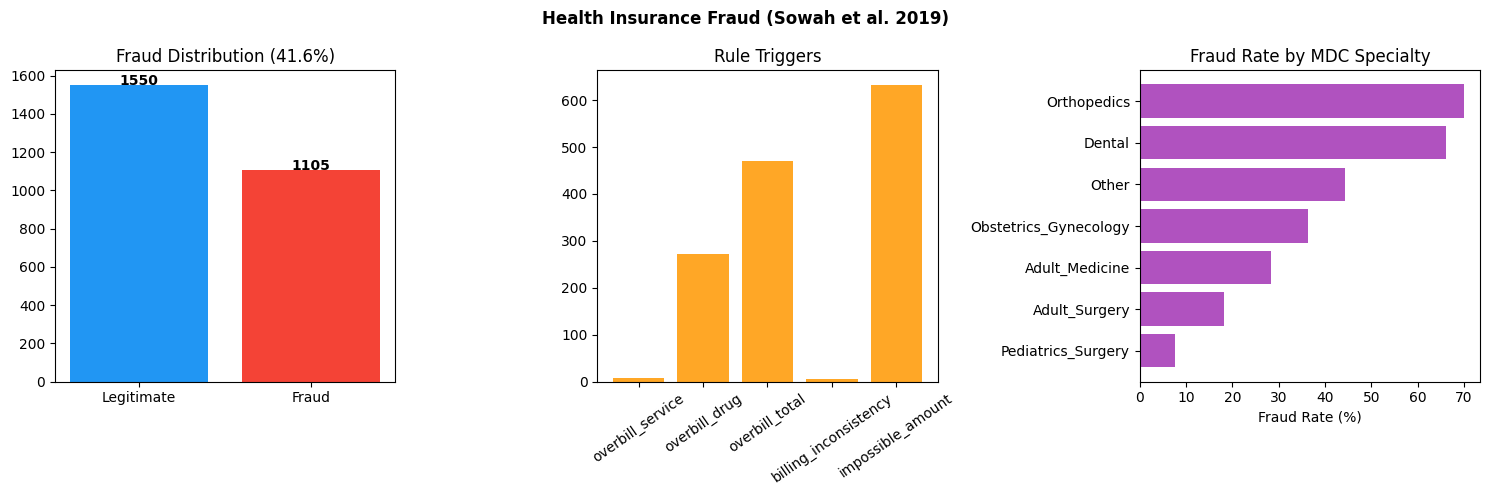

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

counts = merged['fraud_label'].value_counts()
axes[0].bar(['Legitimate','Fraud'], [counts.get(0,0), counts.get(1,0)], color=['#2196F3','#F44336'])
axes[0].set_title(f'Fraud Distribution ({fraud_rate:.1%})')
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

flag_counts = flags.sum()
axes[1].bar(flag_counts.index, flag_counts.values, color='#FF9800', alpha=0.85)
axes[1].set_title('Rule Triggers')
axes[1].tick_params(axis='x', rotation=35)

if 'MDC_Specialty' in merged.columns:
    by_mdc = merged.groupby('MDC_Specialty')['fraud_label'].mean().sort_values()
    axes[2].barh(by_mdc.index, by_mdc.values * 100, color='#9C27B0', alpha=0.8)
    axes[2].set_title('Fraud Rate by MDC Specialty')
    axes[2].set_xlabel('Fraud Rate (%)')

plt.suptitle('Health Insurance Fraud (Sowah et al. 2019)', fontsize=12, fontweight='bold')
plt.tight_layout()
os.makedirs(FIGURE_DIR, exist_ok=True)
plt.savefig(os.path.join(FIGURE_DIR, '01_health_insurance_labels.png'), dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Item | Detail |
|---|---|
| Method | Sowah et al. (2019) G-DRG tariff compliance |
| Join key | `GDRG_Code` (ReData) <-> `Code` (GD.csv) |
| Rules | Overbilling (service/drug/total), inconsistency, impossible amounts |
| Output | `outputs/health_insurance_labeled.csv` |

-> **Next: `02_preprocessing.ipynb`**